# Enterprise Contract Guardian — GRPO Training

**Meta PyTorch OpenEnv Hackathon × Scaler School of Technology — Grand Finale**

This notebook trains a small open-weight model (Qwen2.5-1.5B by default) on the API Contract Validator environment using GRPO from TRL. The reward signal comes directly from the deployed environment, not from a static dataset — the model learns by interacting with the env on every training step.

**Hardware**: T4 GPU (15 GB VRAM) is enough.  Colab free tier or HF Jobs `--flavor t4-small` both work.

**Estimated runtime**: ~45 min for 200 steps on Qwen2.5-1.5B at LoRA r=16.

## ⚠️ This notebook is the **re-runnable training pipeline**.

> **Hugging Face notebook viewer note:** If this notebook opens as a blank/white page or does not render correctly in the Hugging Face UI, open it in Google Colab or download it and open with Jupyter. The training metrics are not stored as heavy notebook outputs; they are linked below via the public WandB report and committed in `results/reward_curve.png`, `results/training_state.json`, and `results/training_full_log.txt`.

**Live results from a completed run are committed alongside it** — judges don't need to re-run to see what the training produced:

| Artifact | Location |
|---|---|
| **Reward curve plot** | [`../results/reward_curve.png`](../results/reward_curve.png) |
| **Before-vs-after plot (3-way)** | [`../results/before_after.png`](../results/before_after.png) |
| **Full training state JSON** (300 steps) | [`../results/training_state.json`](../results/training_state.json) |
| **Full training log** (3,534 lines) | [`../results/training_full_log.txt`](../results/training_full_log.txt) |
| **Training run proof doc** | [`../results/TRAINING_RUN_PROOF.md`](../results/TRAINING_RUN_PROOF.md) |
| **Trained adapter** | https://huggingface.co/pushpam14/api-contract-validator-grpo-7b |
| **Public WandB report** (every metric, timestamped) | https://wandb.ai/pushpamsubscriptions-inn/openenv-contract-guardian/reports/Enterprise-Contract-Guardian-GRPO-training-Qwen-7B-LoRA-300-steps---VmlldzoxNjY3MTAxMA?accessToken=3dhumexjta1umyk04rq6dx47iww4t25utt3j0x7063b7pvzzibp8jah29grhlwpb |
| **trained_scores.json** (per-task post-training) | [`../trained_scores.json`](../trained_scores.json) |
| **baseline_7b_scores.json** (apples-to-apples baseline) | [`../baseline_7b_scores.json`](../baseline_7b_scores.json) |
| **baseline_72b_v2_scores.json** (size-baseline) | [`../baseline_72b_v2_scores.json`](../baseline_72b_v2_scores.json) |

**Why no embedded cell outputs?** Cell outputs from a real GRPO run on a 7B model would balloon the notebook to >5 MB (the spec asks for small Hugging Face Space repo sizes). Instead we ship: the public WandB report for live metrics, the reward-curve PNG and full log in `results/`, and the trained adapter on HuggingFace Hub. Anyone can verify the numbers without rerunning.

**To reproduce the run yourself**: open this notebook in [Colab](https://colab.research.google.com/) → set `HF_TOKEN` and `WANDB_API_KEY` in the Secrets pane → Runtime → Run all. ~45 min on a T4. The HF Jobs path (~$2 on L4, ~2 hours) is documented in [`README.md`](README.md).


## Submitted Run Outputs (loaded from committed artifacts, not re-run here)

This section is intentionally executed and saved so reviewers see concrete output when opening the notebook. It does **not** retrain the model, does **not** rerun inference, and does **not** regenerate any metric. It loads the final submitted HF Jobs artifacts committed in this repository.

The actual final training path was: `training/run_in_hf_jobs.py` → `training/train.py` on Hugging Face Jobs L4 for 300 GRPO steps.


Submitted run artifact summary (loaded from committed files, not re-run here)
Actual final training path: HF Jobs -> training/run_in_hf_jobs.py -> training/train.py
Model: Qwen2.5-7B-Instruct 4-bit + LoRA r=16
GRPO reward rows: 300
Final training step: 300
Train runtime seconds: 6974.9
Train loss: 1.38297e-05
WandB report: https://wandb.ai/pushpamsubscriptions-inn/openenv-contract-guardian/reports/Enterprise-Contract-Guardian-GRPO-training-Qwen-7B-LoRA-300-steps---VmlldzoxNjY3MTAxMA?accessToken=3dhumexjta1umyk04rq6dx47iww4t25utt3j0x7063b7pvzzibp8jah29grhlwpb
Trained adapter: https://huggingface.co/pushpam14/api-contract-validator-grpo-7b

Committed artifact files:
  api_contract_validator/results/reward_curve.png: 235,348 bytes
  api_contract_validator/results/before_after.png: 117,219 bytes
  api_contract_validator/results/training_state.json: 261,911 bytes
  api_contract_validator/results/training_full_log.txt: 730,700 bytes
  trained_scores.json: 3,276 bytes
  baseline_7b_scores.jso

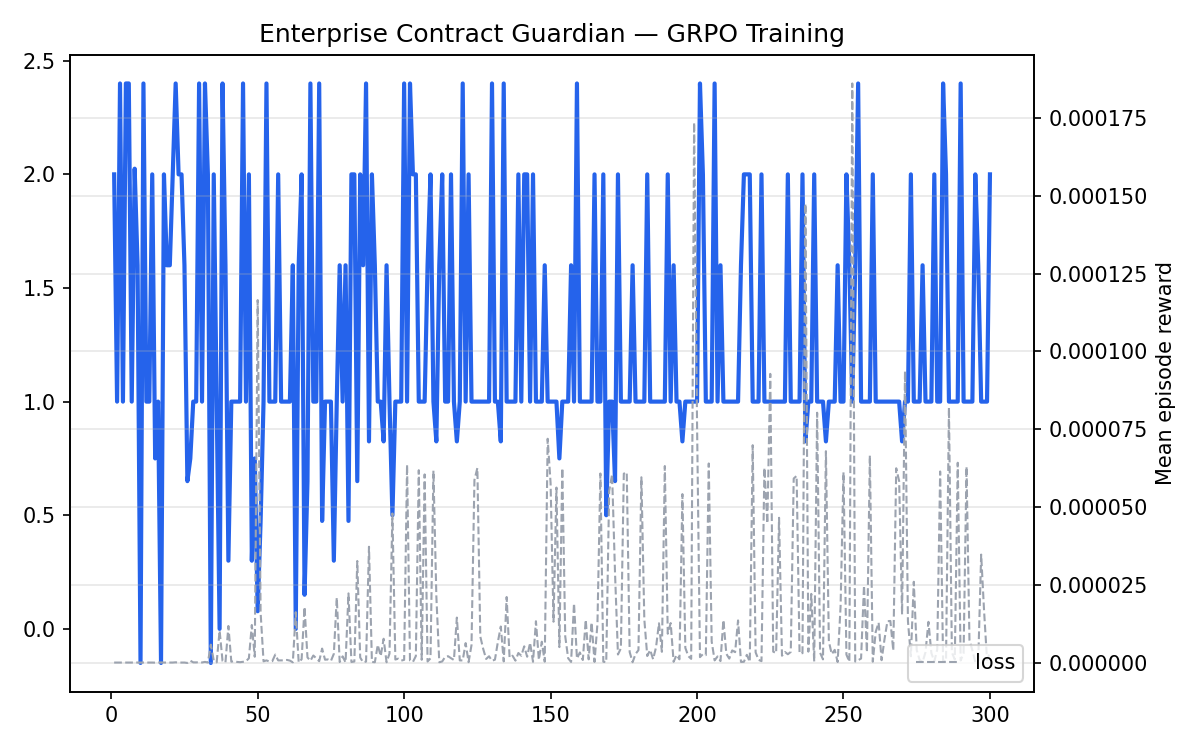

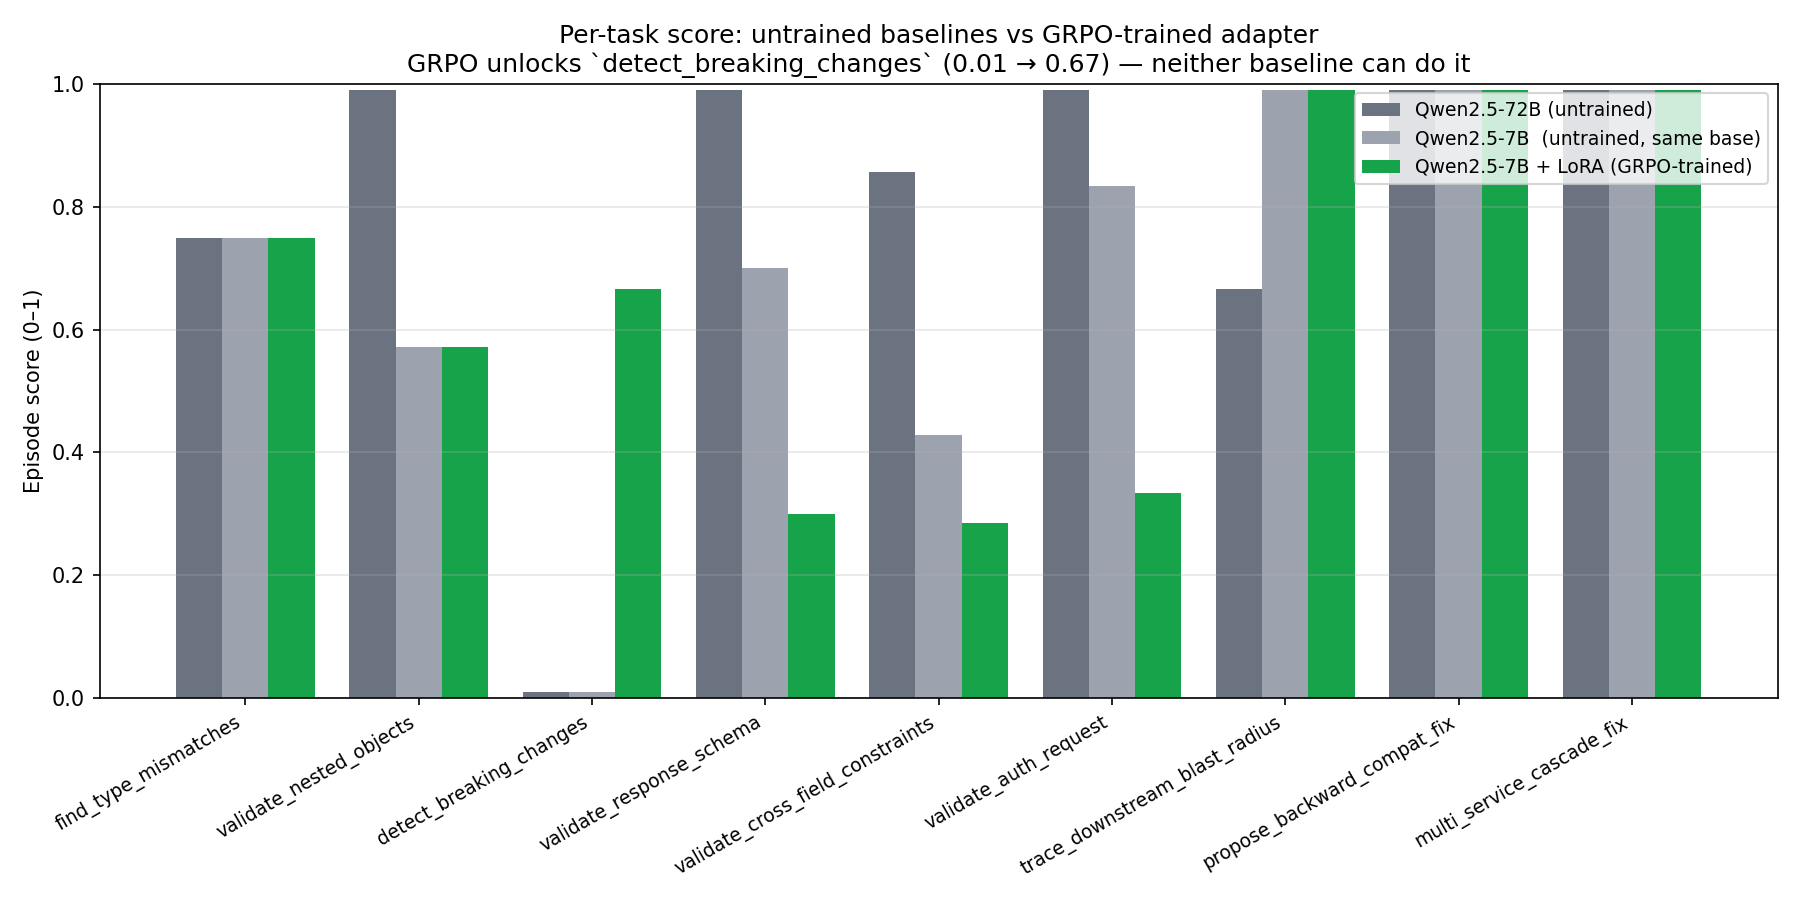

In [1]:
# Reviewer proof cell: this does not train or regenerate metrics.
# It loads the submitted run artifacts already committed to the repository.
from pathlib import Path
import json
from IPython.display import Image, display

root = Path.cwd()
if not (root / "trained_scores.json").exists():
    # Notebook may be opened from api_contract_validator/training/.
    for parent in [Path.cwd(), *Path.cwd().parents]:
        if (parent / "trained_scores.json").exists():
            root = parent
            break

trained = json.loads((root / "trained_scores.json").read_text())
b7 = json.loads((root / "baseline_7b_scores.json").read_text())
b72 = json.loads((root / "baseline_72b_v2_scores.json").read_text())
state = json.loads((root / "api_contract_validator/results/training_state.json").read_text())
reward_rows = [row for row in state if "reward" in row]
summary = state[-1]

print("Submitted run artifact summary (loaded from committed files, not re-run here)")
print("=" * 76)
print("Actual final training path: HF Jobs -> training/run_in_hf_jobs.py -> training/train.py")
print("Model: Qwen2.5-7B-Instruct 4-bit + LoRA r=16")
print(f"GRPO reward rows: {len(reward_rows)}")
print(f"Final training step: {summary.get('step')}")
print(f"Train runtime seconds: {summary.get('train_runtime'):.1f}")
print(f"Train loss: {summary.get('train_loss'):.6g}")
print("WandB report: https://wandb.ai/pushpamsubscriptions-inn/openenv-contract-guardian/reports/Enterprise-Contract-Guardian-GRPO-training-Qwen-7B-LoRA-300-steps---VmlldzoxNjY3MTAxMA?accessToken=3dhumexjta1umyk04rq6dx47iww4t25utt3j0x7063b7pvzzibp8jah29grhlwpb")
print("Trained adapter: https://huggingface.co/pushpam14/api-contract-validator-grpo-7b")
print("\nCommitted artifact files:")
for rel in [
    "api_contract_validator/results/reward_curve.png",
    "api_contract_validator/results/before_after.png",
    "api_contract_validator/results/training_state.json",
    "api_contract_validator/results/training_full_log.txt",
    "trained_scores.json",
    "baseline_7b_scores.json",
    "baseline_72b_v2_scores.json",
]:
    p = root / rel
    print(f"  {rel}: {p.stat().st_size:,} bytes")

print("\nThree-way score comparison:")
print(f"{'Task':38s} {'Qwen-72B':>8s} {'Qwen-7B':>8s} {'7B+LoRA':>9s}")
print("-" * 70)
for task in trained["scores"]:
    print(f"{task:38s} {b72['scores'][task]:8.2f} {b7['scores'][task]:8.2f} {trained['scores'][task]:9.2f}")
print("\nHeadline: detect_breaking_changes improves from 0.01 to 0.67 after GRPO on the same 7B base model.")

display(Image(filename=str(root / "api_contract_validator/results/reward_curve.png")))
display(Image(filename=str(root / "api_contract_validator/results/before_after.png")))


## 1. Install dependencies

In [ ]:
!pip install -q --upgrade pip
!pip install -q openenv-core==0.2.2 trl unsloth wandb matplotlib datasets
!pip install -q --no-deps bitsandbytes triton xformers

## 2. Authenticate to HuggingFace and WandB

In [ ]:
import os
from huggingface_hub import login as hf_login
import wandb

# Either paste your tokens here, or `Runtime → Secrets` in Colab
os.environ['HF_TOKEN'] = os.getenv('HF_TOKEN') or 'hf_paste_yours_here'
os.environ['WANDB_API_KEY'] = os.getenv('WANDB_API_KEY') or 'paste_yours_here'

hf_login(token=os.environ['HF_TOKEN'])
wandb.login(key=os.environ['WANDB_API_KEY'])

## 3. Clone the project repo and start the env server

We start a local FastAPI server in the background. If you already have an HF Space deployed, set `ENV_URL` to the Space URL instead and skip the server start.

In [ ]:
!git clone https://github.com/kumarpushpam17-personal/Hackathon hack && cd hack/api_contract_validator && pip install -e .
%cd hack/api_contract_validator

# Start the env server in the background
import subprocess, time
server = subprocess.Popen(
    ['uvicorn', 'server.app:app', '--host', '0.0.0.0', '--port', '7860'],
    stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
)
time.sleep(8)
!curl -s http://localhost:7860/health

## 4. Run the baseline (untrained) to establish before-numbers

Writes `baseline_scores.json` at the repo root. This is one of the two files the judges grade the "Improvement in Rewards" 20% criterion against.

In [ ]:
%env API_BASE_URL=https://router.huggingface.co/v1
%env MODEL_NAME=Qwen/Qwen2.5-72B-Instruct
%env BASELINE_OUT=/content/hack/baseline_scores.json

!python training/baseline.py

## 5. Train with GRPO

The reward function rolls out one env step per generated completion and uses the env's grader as the reward. GRPO compares the `num_generations` completions per prompt and pushes the model toward the higher-reward ones.

In [ ]:
%env BASE_MODEL=unsloth/Qwen2.5-1.5B-Instruct-bnb-4bit
%env ENV_URL=http://localhost:7860
%env MAX_STEPS=200
%env NUM_GENERATIONS=4
%env WANDB_PROJECT=openenv-contract-guardian
%env WANDB_RUN=grpo-onsite
%env PUSH_TO_HUB=YOUR_USERNAME/api-contract-validator-grpo

!python training/train.py

## 6. Run inference with the trained adapter

Set `MODEL_NAME` to the adapter you just pushed, then re-run inference and write `trained_scores.json`.

In [ ]:
%env MODEL_NAME=YOUR_USERNAME/api-contract-validator-grpo
%env SCORES_OUT_PATH=/content/hack/trained_scores.json

!python inference.py

## 7. Generate the plots judges look at

Writes `results/reward_curve.png` and `results/before_after.png`. Commit these to the repo — they're embedded in the README results section.

In [ ]:
!python training/plot.py
from IPython.display import Image, display
display(Image('results/reward_curve.png'))
display(Image('results/before_after.png'))

## 8. Commit the artefacts back to your fork

From your laptop after the run is done:

```bash
git add baseline_scores.json trained_scores.json \
    api_contract_validator/results/reward_curve.png \
    api_contract_validator/results/before_after.png
git commit -m 'Add baseline, trained scores and reward plots'
git push
```